In [1]:
from pathlib import Path

import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
# pd.set_option("display.max_colwidth", None)
# pd.set_option("display.max_seq_items", None)

In [2]:
df = pd.read_parquet(Path("..") / "data" / "features" / "match_features.parquet")
df.head()

,match_id,match_date,region,year,split,stage,blue_win,first_pick_side,blue_team_name,red_team_name,blue_top_player,blue_jungle_player,blue_mid_player,blue_bot_player,blue_support_player,red_top_player,red_jungle_player,red_mid_player,red_bot_player,red_support_player,blue_top_champion,blue_jungle_champion,blue_mid_champion,blue_bot_champion,blue_support_champion,red_top_champion,red_jungle_champion,red_mid_champion,red_bot_champion,red_support_champion,blue_has_first_pick,is_international,blue_team_split_games_before,blue_team_split_win_rate_before,blue_top_champion_role_games_before,blue_top_champion_role_win_rate_before,blue_top_player_champion_games_last_2y,blue_top_player_champion_win_rate_last_2y,blue_jungle_champion_role_games_before,blue_jungle_champion_role_win_rate_before,blue_jungle_player_champion_games_last_2y,blue_jungle_player_champion_win_rate_last_2y,blue_mid_champion_role_games_before,blue_mid_champion_role_win_rate_before,blue_mid_player_champion_games_last_2y,blue_mid_player_champion_win_rate_last_2y,blue_bot_champion_role_games_before,blue_bot_champion_role_win_rate_before,blue_bot_player_champion_games_last_2y,blue_bot_player_champion_win_rate_last_2y,blue_support_champion_role_games_before,blue_support_champion_role_win_rate_before,blue_support_player_champion_games_last_2y,blue_support_player_champion_win_rate_last_2y,red_team_split_games_before,red_team_split_win_rate_before,red_top_champion_role_games_before,red_top_champion_role_win_rate_before,red_top_player_champion_games_last_2y,red_top_player_champion_win_rate_last_2y,red_jungle_champion_role_games_before,red_jungle_champion_role_win_rate_before,red_jungle_player_champion_games_last_2y,red_jungle_player_champion_win_rate_last_2y,red_mid_champion_role_games_before,red_mid_champion_role_win_rate_before,red_mid_player_champion_games_last_2y,red_mid_player_champion_win_rate_last_2y,red_bot_champion_role_games_before,red_bot_champion_role_win_rate_before,red_bot_player_champion_games_last_2y,red_bot_player_champion_win_rate_last_2y,red_support_champion_role_games_before,red_support_champion_role_win_rate_before,red_support_player_champion_games_last_2y,red_support_player_champion_win_rate_last_2y,team_split_win_rate_diff
0,35847,2022-01-10,LPL,2022,Spring,WEEK1,True,blue,OMG,TT,shanji,AKi,Creme,Able,cold,New,Moyan,Captain,Puff,Southwind,Gwen,Jarvan IV,Syndra,Jinx,Nautilus,Jax,Xin Zhao,Vex,Aphelios,Thresh,True,False,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.500000,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0.0
1,35848,2022-01-10,LPL,2022,Spring,WEEK1,True,blue,OMG,TT,shanji,AKi,Creme,Able,cold,New,Moyan,Captain,Puff,Southwind,Rumble,Xin Zhao,Corki,Jinx,Rakan,Gangplank,Lee Sin,Twisted Fate,Ziggs,Leona,True,False,1,1.0,0,0.5,0,0.5,1,0.0,0,0.5,0,0.5,0,0.5,1,1.0,1,1.0,0,0.5,0,0.5,1,0.0,0,0.5,0,0.5,0,0.500000,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,1.0
2,35850,2022-01-10,LPL,2022,Spring,WEEK1,True,blue,FPX,RNG,Xiaolaohu,Beichuan,Gori,Lwx,Hang,Bin,Wei,xiaohu,GALA,Ming,Graves,Viego,Corki,Jinx,Thresh,Jayce,Xin Zhao,Viktor,Jhin,Sett,True,False,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,1,1.0,0,0.5,2,1.0,0,0.5,1,0.0,0,0.5,0,0.5,0,0.5,0,0.5,2,0.500000,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,0.0
3,35851,2022-01-10,LPL,2022,Spring,WEEK1,False,blue,FPX,RNG,Xiaolaohu,Beichuan,Gori,Lwx,Hang,Bin,Wei,xiaohu,GALA,Ming,Gwen,Viego,Viktor,Caitlyn,Lux,Jax,Xin Zhao,Zoe,Jhin,Karma,True,False,1,1.0,1,1.0,0,0.5,1,1.0,1,1.0,1,0.0,0,0.5,0,0.5,0,0.5,0,0.5,0,0.5,1,0.0,1,0.0,0,0.5,3,0.333333,1,0.0,0,0.5,0,0.5,1,0.0,1,0.0,0,0.5,0,0.5,1.0
4,35852,2022-01-10,LPL,2022,Spring,WEEK1,False,blue,FPX,RNG,Bin,Wei,xiaohu,GALA,Ming,Xiaolaohu,Beichuan,Gori,Lwx,Hang,Gwen,Jarvan IV,Syndra,Jinx,Thresh,Jayce,Lee Sin,Corki,Aphelios,Lulu,True,False,2,0.5,2,0.5,0,0.5,1,1.0,0,0.5,1,1.0,0,0.5,3,1.0,0,0.5,2,0.5,0,0.5,2,0.5,1,0.0,0,0.5,1,0.000000,0,0.5,2,1.0,1,1.0,1,0.0,0,0.5,0,0.5,0,0.5,0.0


In [3]:
df.columns

Index(['match_id', 'match_date', 'region', 'year', 'split', 'stage',
       'blue_win', 'first_pick_side', 'blue_team_name', 'red_team_name',
       'blue_top_player', 'blue_jungle_player', 'blue_mid_player',
       'blue_bot_player', 'blue_support_player', 'red_top_player',
       'red_jungle_player', 'red_mid_player', 'red_bot_player',
       'red_support_player', 'blue_top_champion', 'blue_jungle_champion',
       'blue_mid_champion', 'blue_bot_champion', 'blue_support_champion',
       'red_top_champion', 'red_jungle_champion', 'red_mid_champion',
       'red_bot_champion', 'red_support_champion', 'blue_has_first_pick',
       'is_international', 'blue_team_split_games_before',
       'blue_team_split_win_rate_before',
       'blue_top_champion_role_games_before',
       'blue_top_champion_role_win_rate_before',
       'blue_top_player_champion_games_last_2y',
       'blue_top_player_champion_win_rate_last_2y',
       'blue_jungle_champion_role_games_before',
       'blue_jungle_ch

In [4]:
for col in df.columns:
    values = sorted(df[col].dropna().unique())
    print(f"\n{col} ({len(values)} unique)")
    print(", ".join(map(str, values)))


match_id (8677 unique)
35817, 35818, 35820, 35821, 35823, 35824, 35825, 35826, 35827, 35829, 35830, 35832, 35833, 35834, 35835, 35836, 35838, 35839, 35841, 35842, 35843, 35844, 35845, 35846, 35847, 35848, 35850, 35851, 35852, 35853, 35854, 35856, 35857, 35858, 35859, 35860, 35862, 35863, 35865, 35866, 35868, 35869, 35871, 35872, 35874, 35875, 35877, 35878, 35879, 35880, 35881, 35883, 35884, 35885, 35886, 35887, 35888, 35889, 35890, 35892, 35893, 35894, 35895, 35896, 35897, 35898, 35899, 35900, 35901, 35902, 35903, 35904, 35905, 35906, 35907, 35908, 35909, 35910, 35911, 35912, 35913, 35914, 35915, 35916, 35917, 35918, 35919, 35920, 35921, 35922, 35923, 35924, 35925, 35926, 35927, 35928, 35929, 35930, 35931, 35932, 36136, 36137, 36138, 36139, 36140, 36142, 36143, 36145, 36146, 36148, 36149, 36151, 36152, 36153, 36154, 36155, 36157, 36158, 36159, 36160, 36161, 36163, 36164, 36166, 36167, 36169, 36170, 36172, 36173, 36175, 36176, 36177, 36178, 36179, 36180, 36181, 36182, 36184, 36185, 361

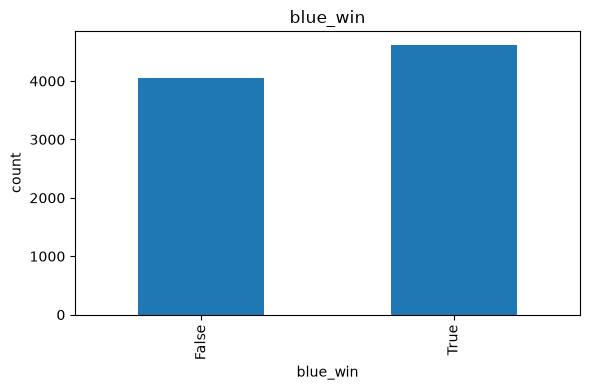

<Figure size 700x400 with 0 Axes>

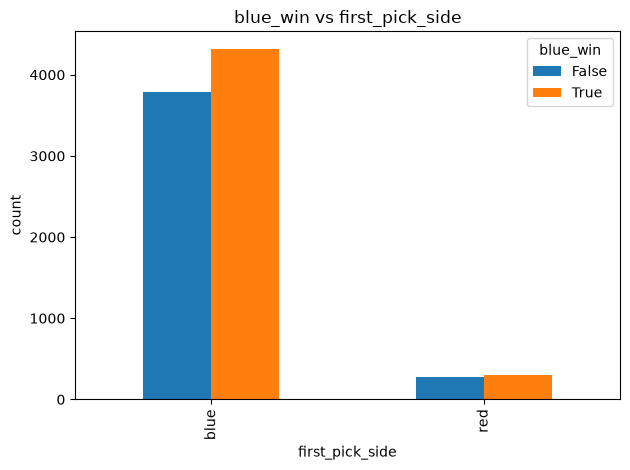

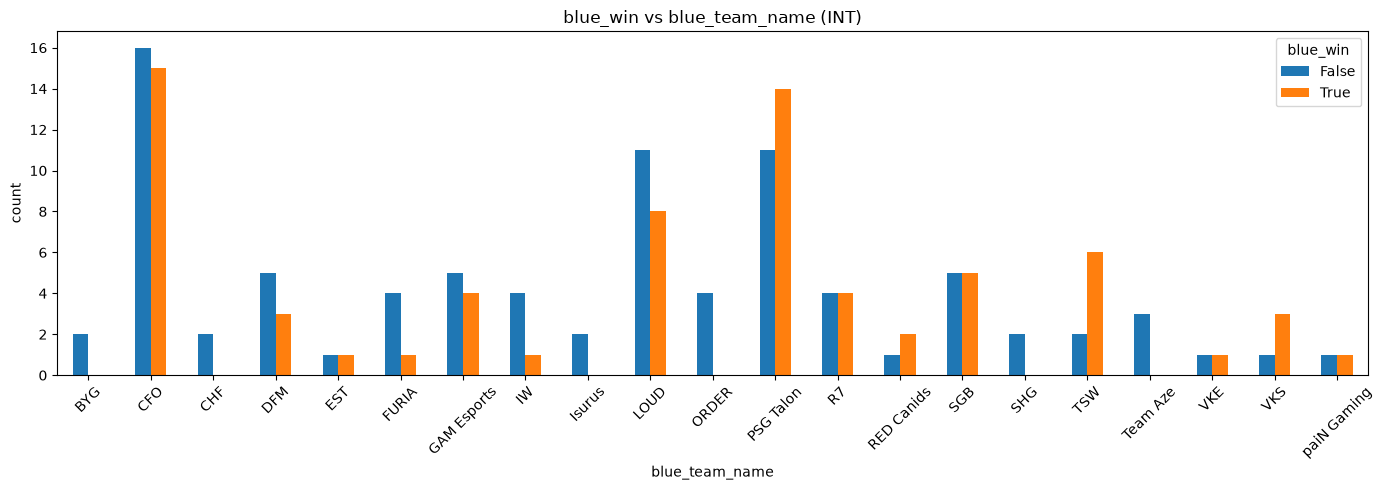

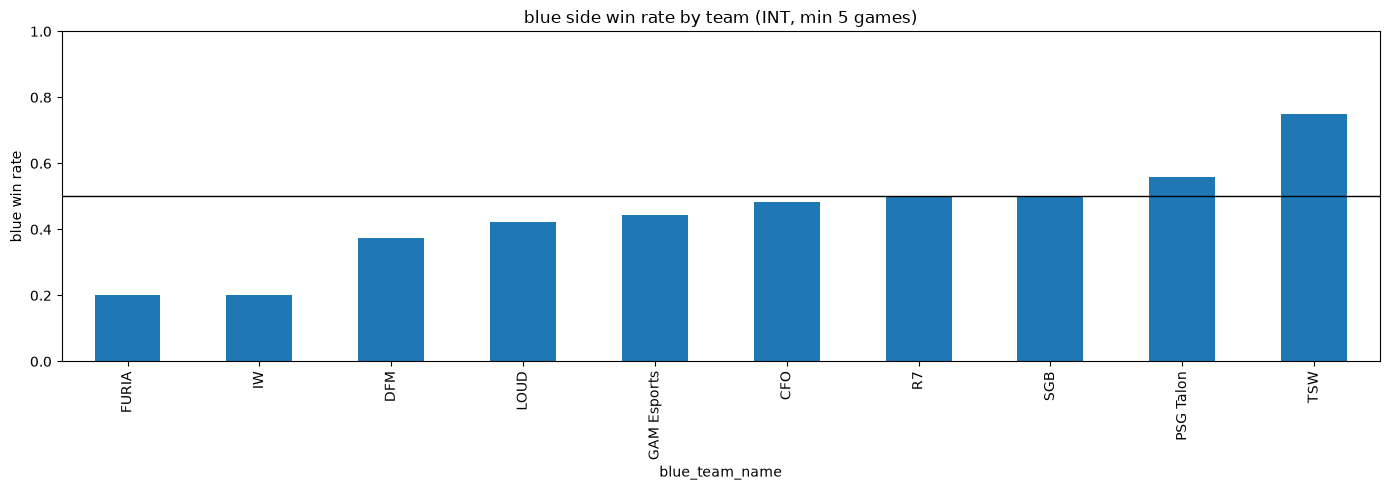

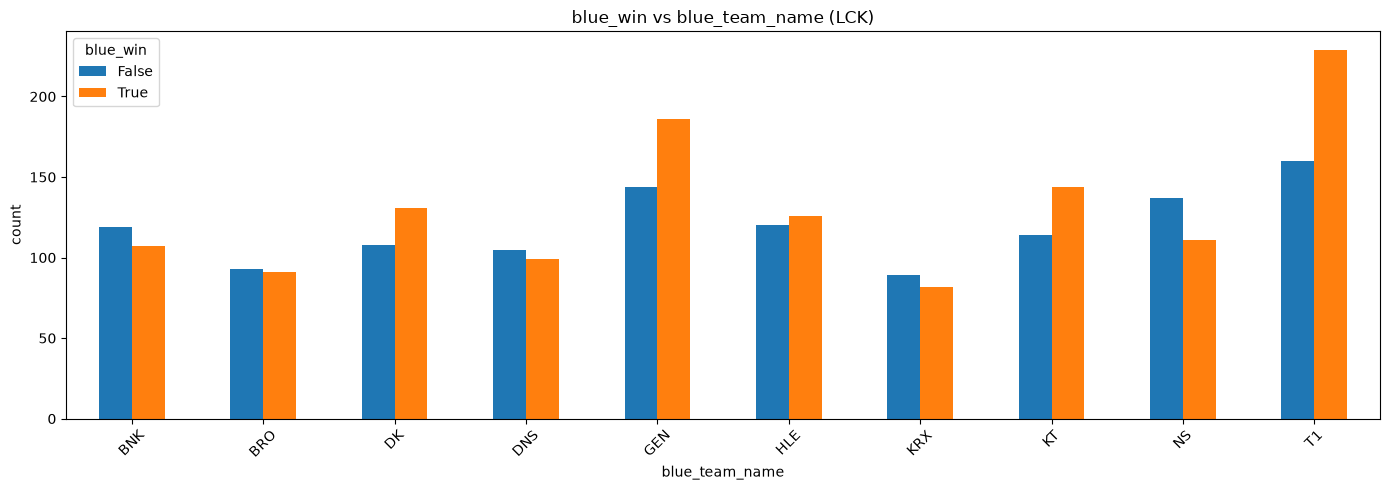

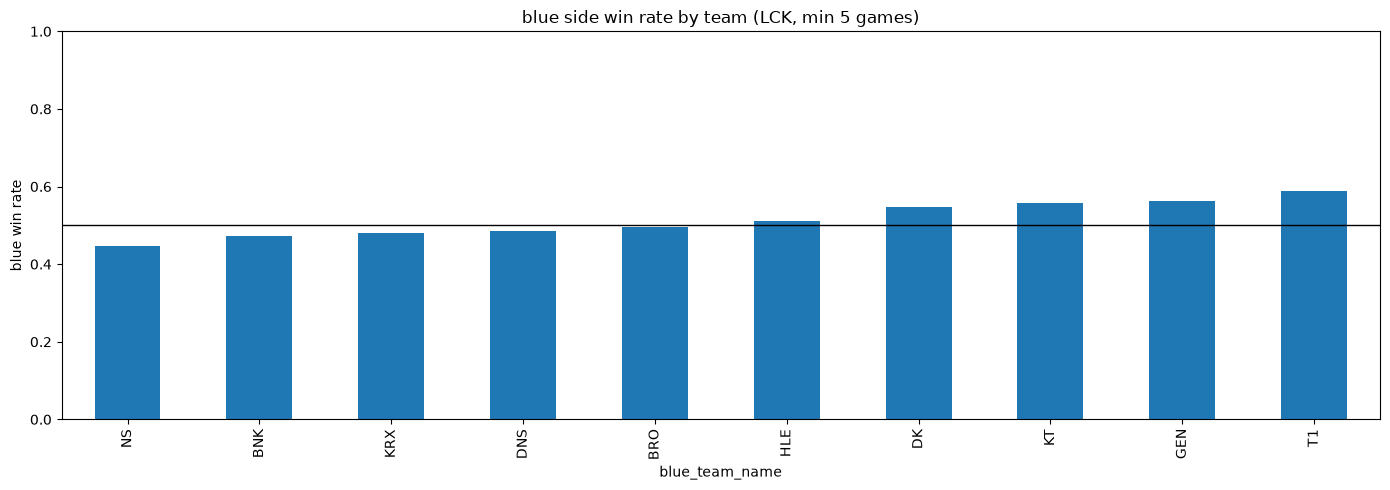

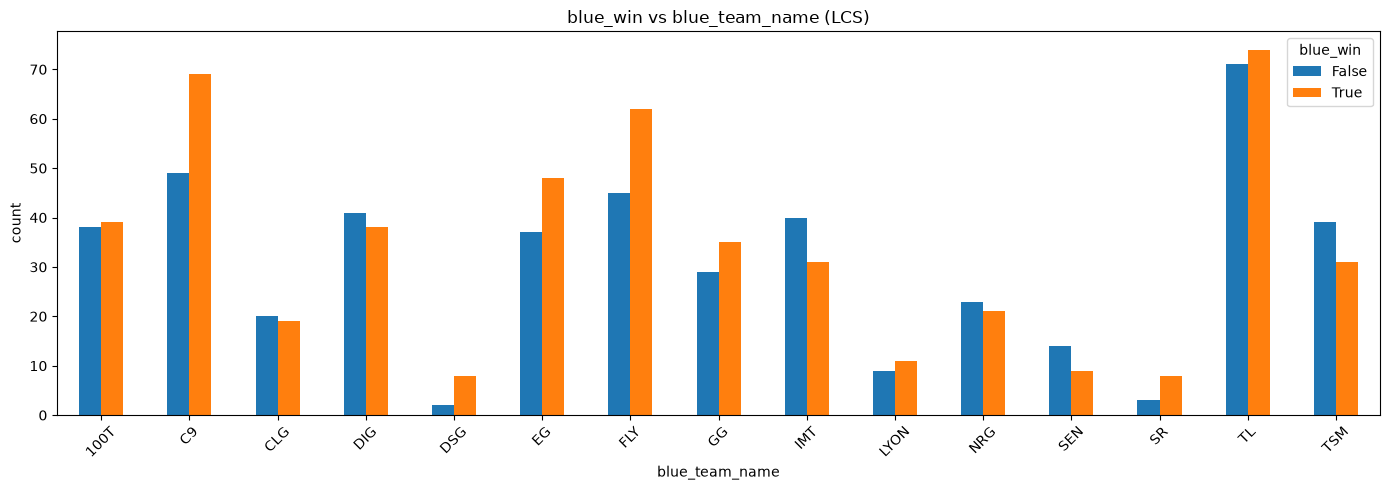

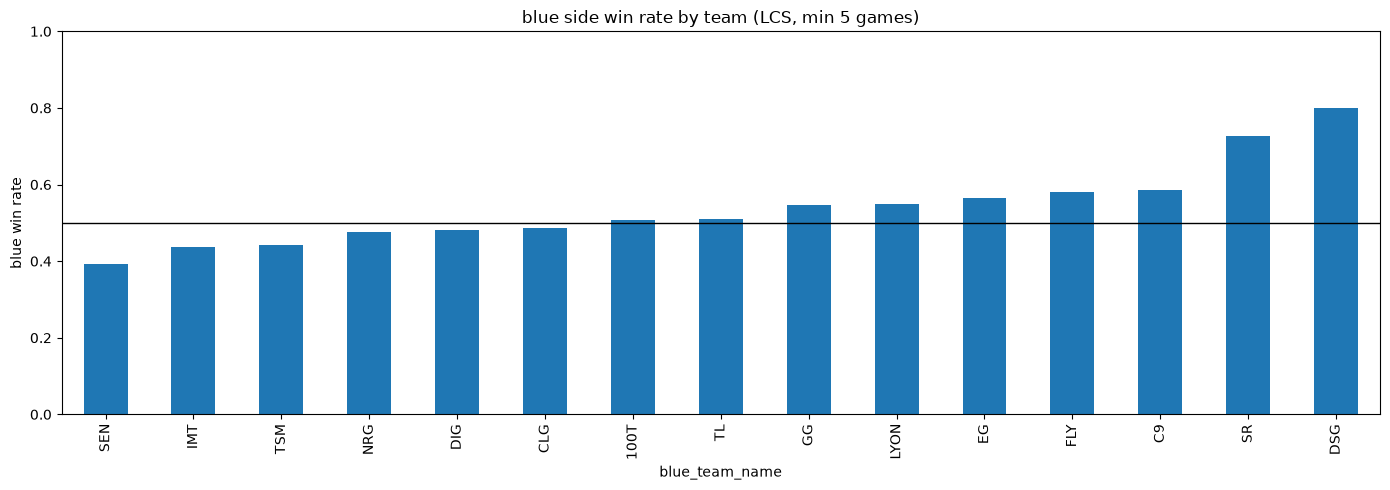

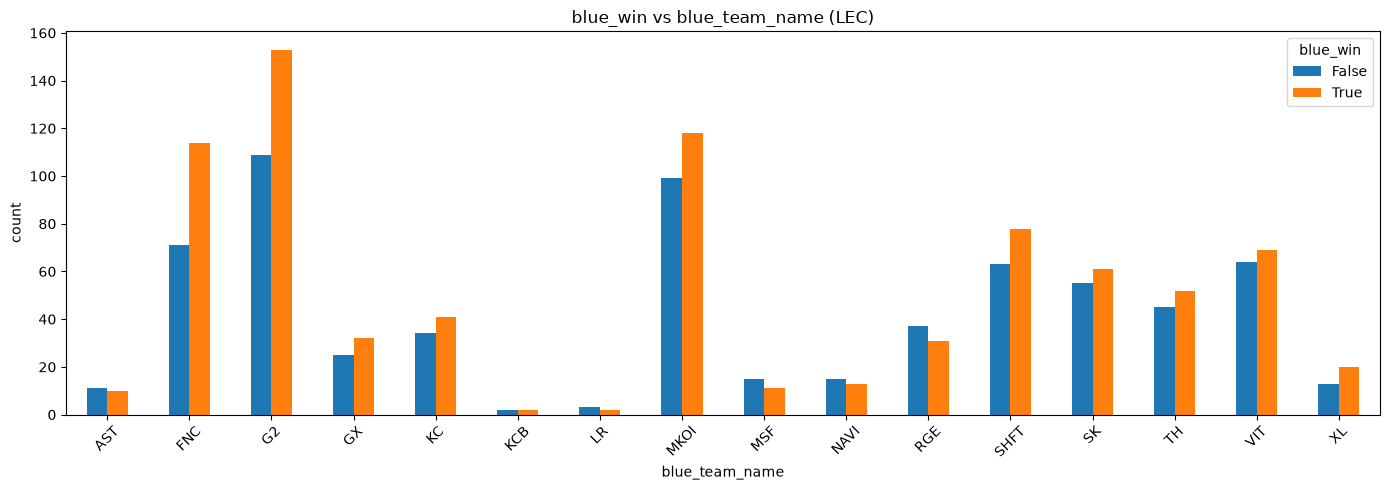

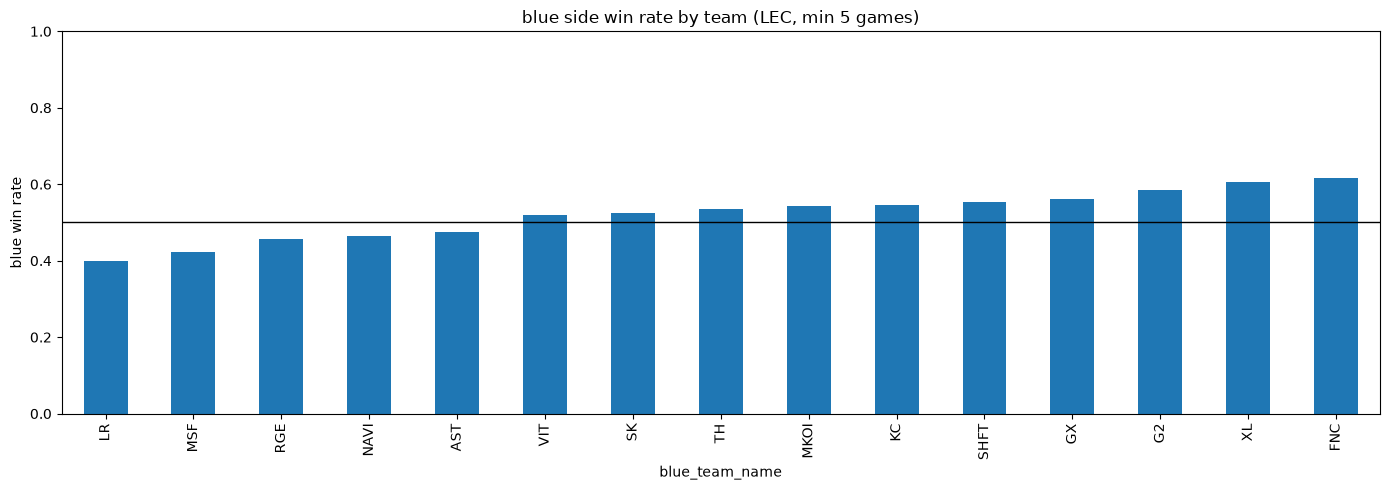

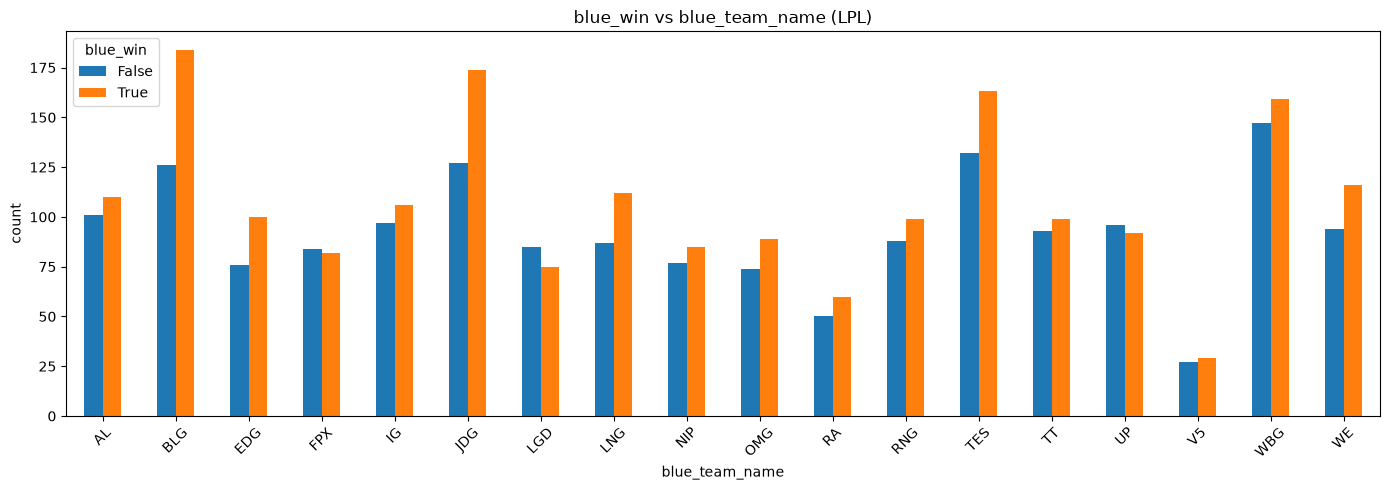

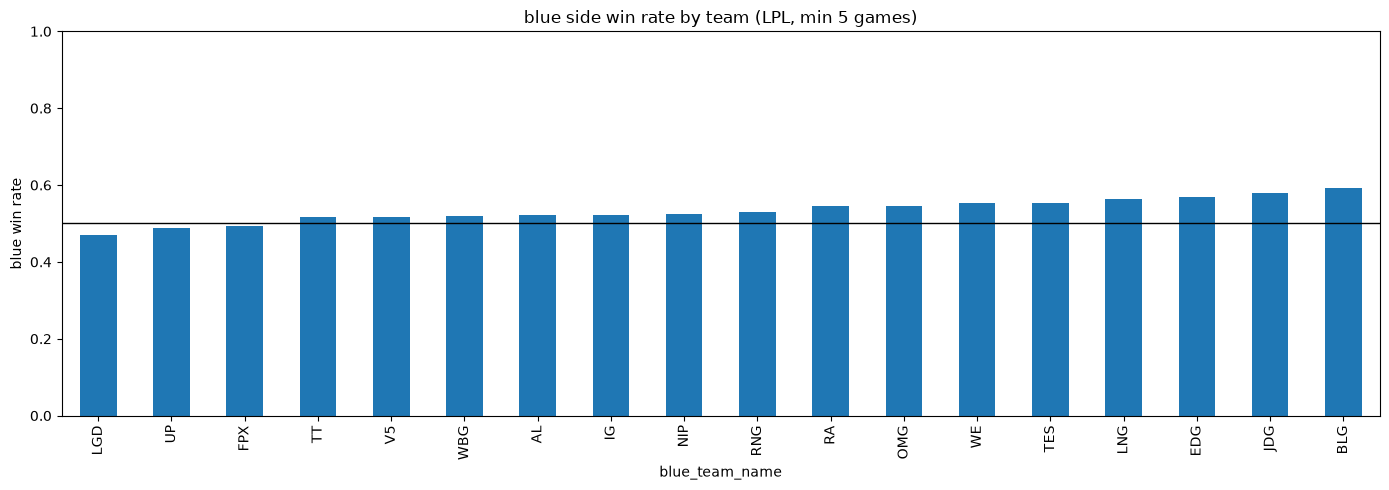

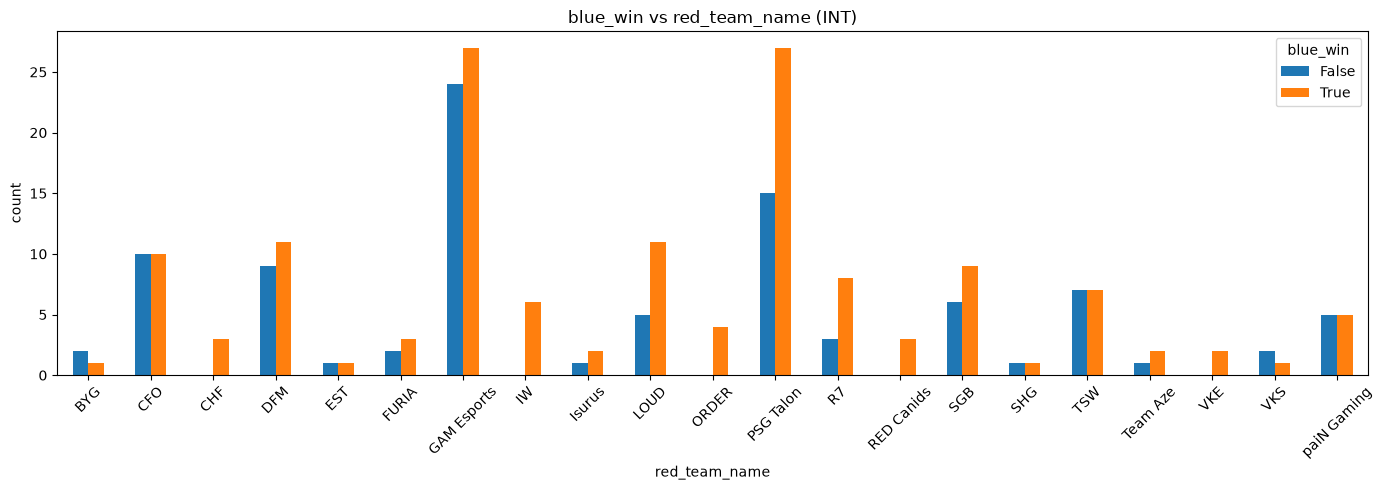

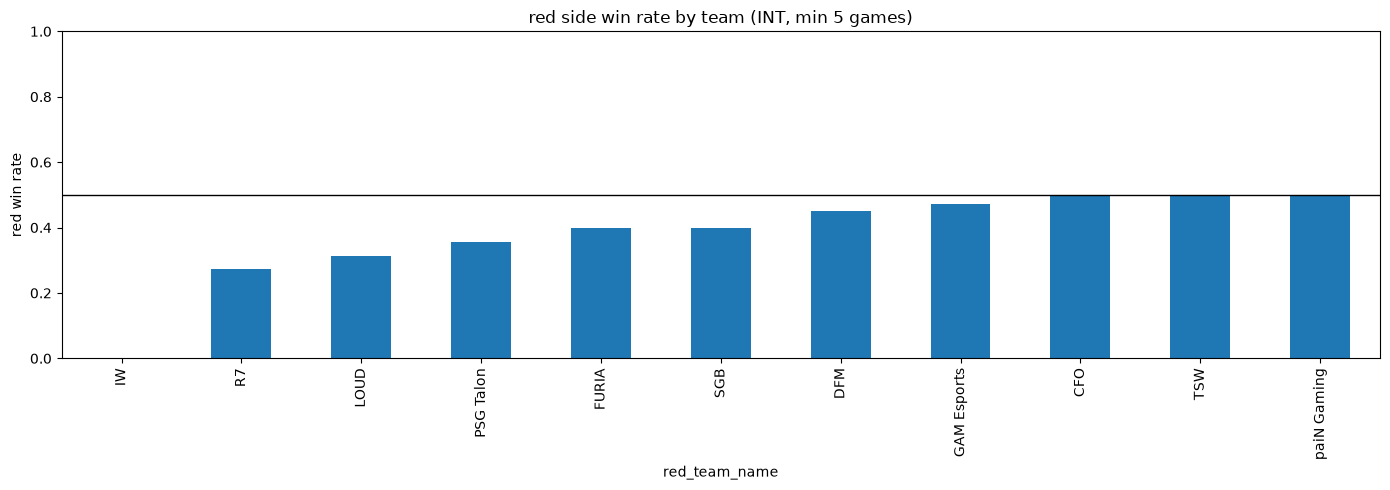

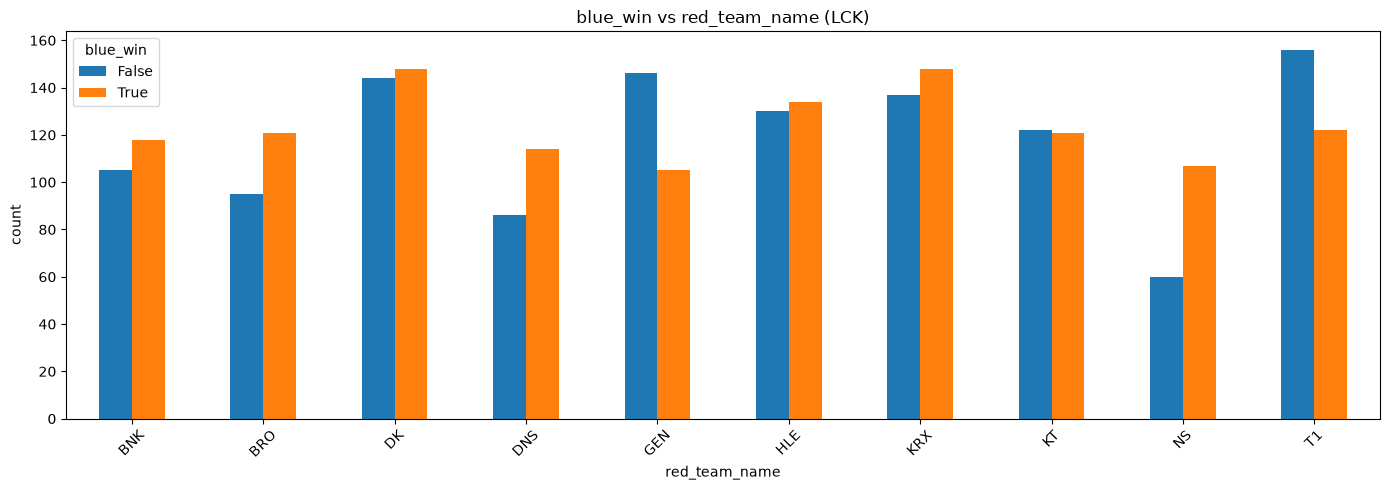

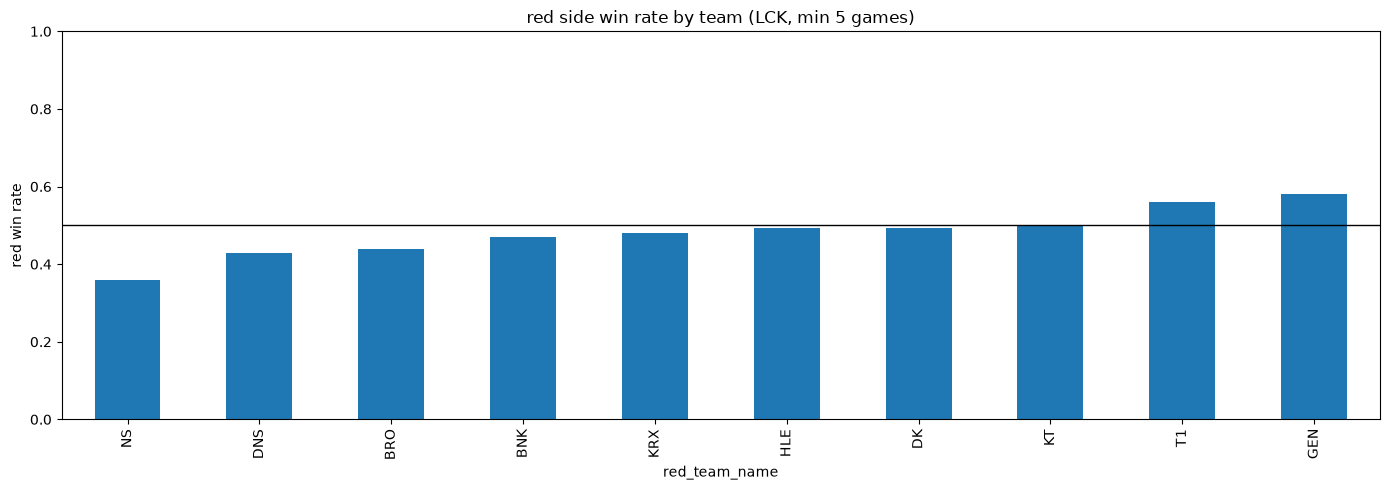

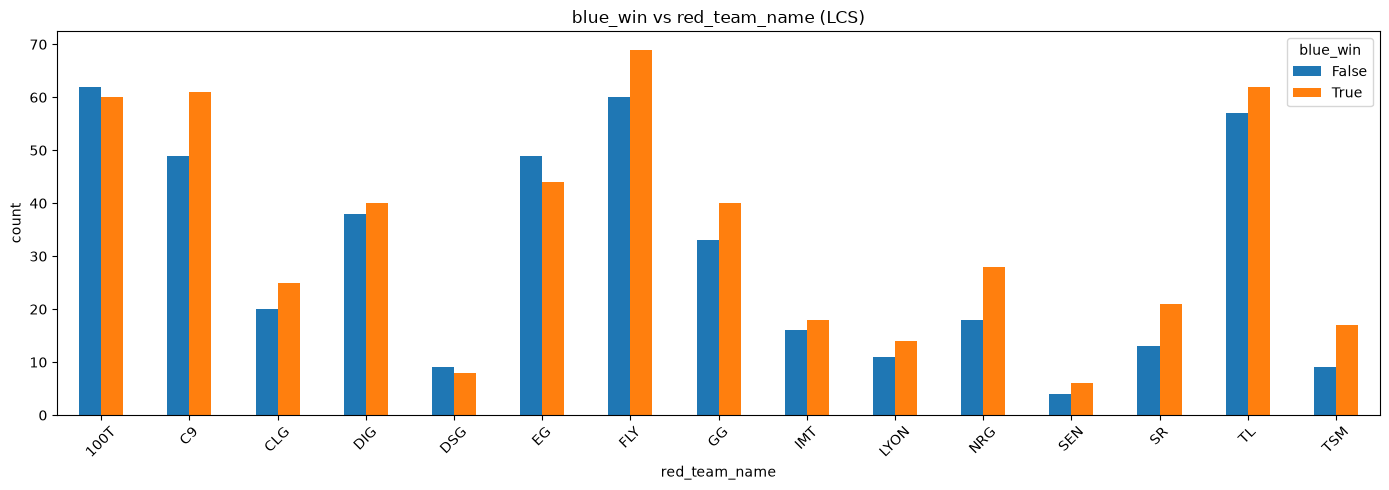

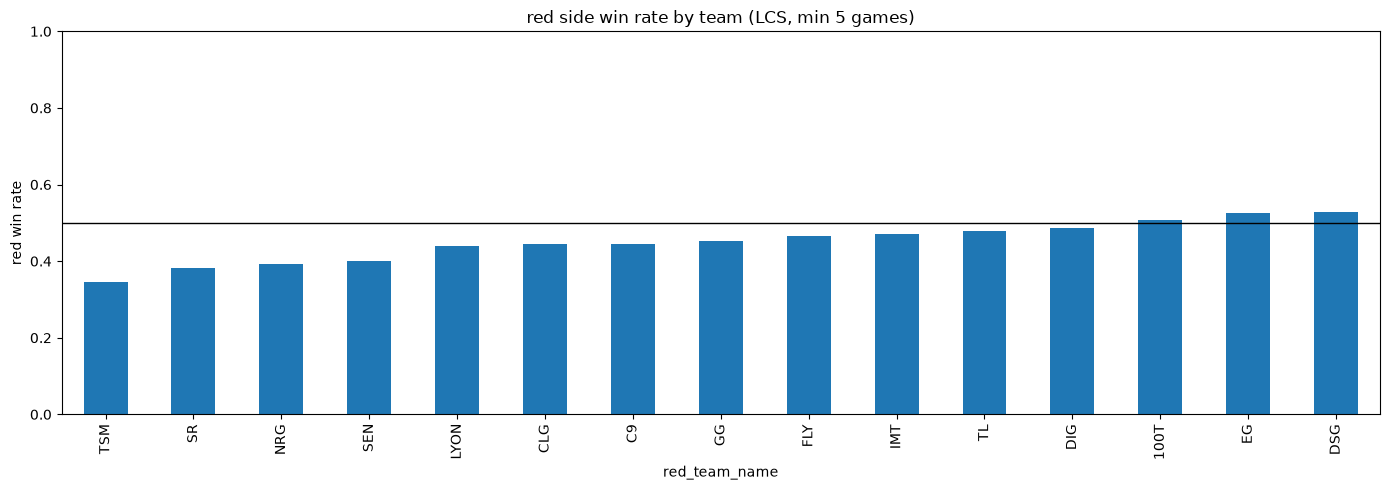

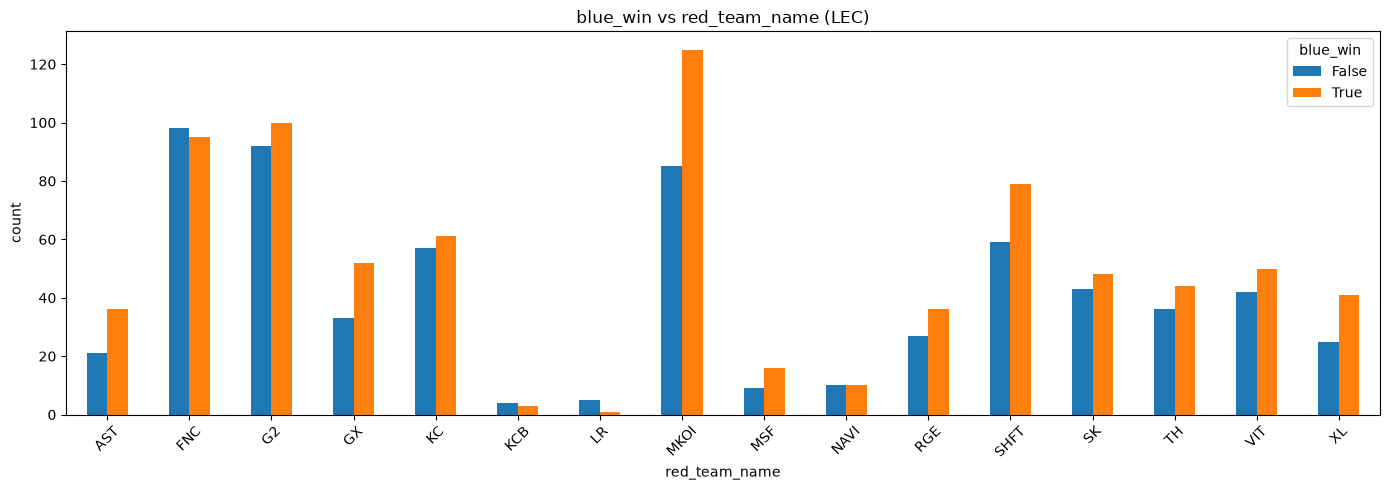

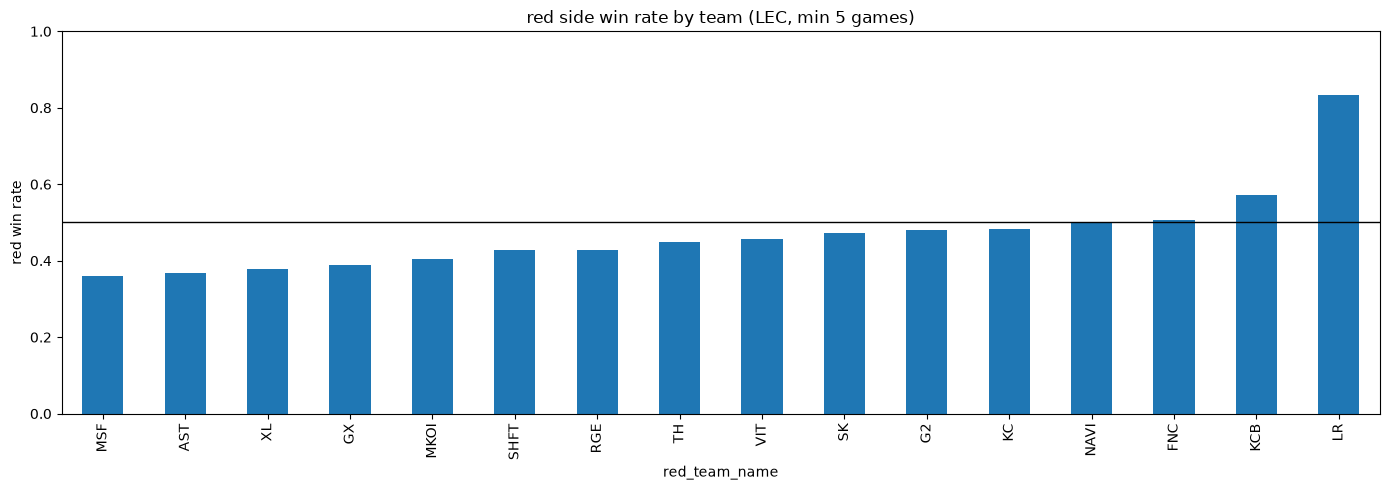

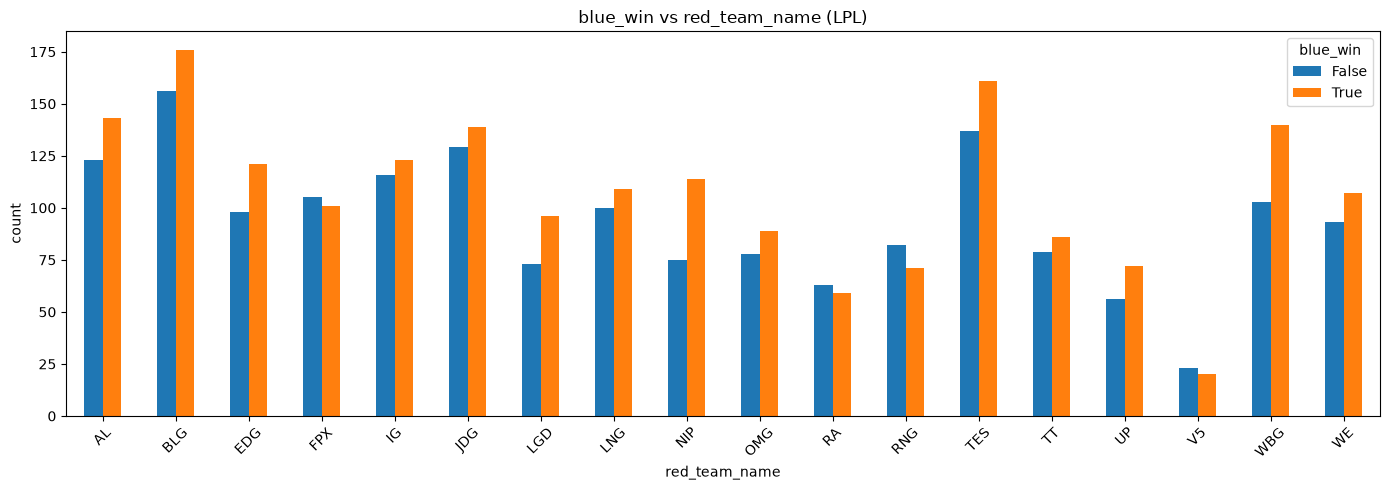

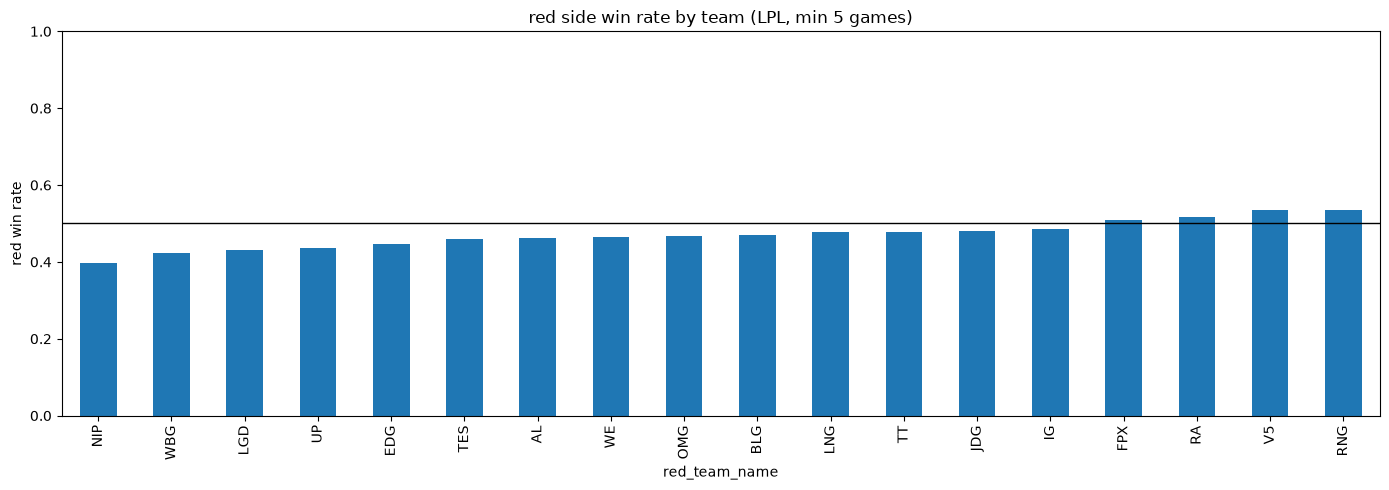

In [5]:
# Team home region from non-INT appearances across both sides.
team_region_rows = pd.concat(
    [
        df.loc[df["region"] != "INT", ["region", "blue_team_name"]].rename(columns={"blue_team_name": "team"}),
        df.loc[df["region"] != "INT", ["region", "red_team_name"]].rename(columns={"red_team_name": "team"}),
    ],
    ignore_index=True,
)

team_home_region = (
    team_region_rows
    .groupby("team")["region"]
    .agg(lambda s: s.value_counts().idxmax())
    .to_dict()
)

def plotting_region(row, team_col):
    if row["region"] != "INT":
        return row["region"]
    return team_home_region.get(row[team_col], "INT")

# 1. blue_win count
plt.figure(figsize=(6, 4))
df["blue_win"].value_counts().sort_index().plot(kind="bar")
plt.title("blue_win")
plt.xlabel("blue_win")
plt.ylabel("count")
plt.tight_layout()
plt.show()


# 2. blue_win vs first_pick_side
plt.figure(figsize=(7, 4))
pd.crosstab(df["first_pick_side"], df["blue_win"]).plot(kind="bar")
plt.title("blue_win vs first_pick_side")
plt.xlabel("first_pick_side")
plt.ylabel("count")
plt.tight_layout()
plt.show()


# 3. blue_win vs blue_team_name, split by adjusted region
min_games = 5
blue_df = df.copy()
blue_df["plot_region"] = blue_df.apply(lambda row: plotting_region(row, "blue_team_name"), axis=1)

for region in sorted(blue_df["plot_region"].unique()):
    region_df = blue_df[blue_df["plot_region"] == region]
    counts = pd.crosstab(region_df["blue_team_name"], region_df["blue_win"])

    ax = counts.plot(kind="bar", figsize=(14, 5))
    ax.set_title(f"blue_win vs blue_team_name ({region})")
    ax.set_xlabel("blue_team_name")
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

    # blue win rate by blue team
    losses = counts.get(False, 0)
    wins = counts.get(True, 0)
    total = wins + losses

    win_rate = (wins / total).loc[total >= min_games].sort_values()

    ax = win_rate.plot(kind="bar", figsize=(14, 5))
    ax.axhline(0.5, color="black", linewidth=1)
    ax.set_title(f"blue side win rate by team ({region}, min {min_games} games)")
    ax.set_xlabel("blue_team_name")
    ax.set_ylabel("blue win rate")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()
    plt.show()


# 4. blue_win vs red_team_name, split by adjusted region
red_df = df.copy()
red_df["plot_region"] = red_df.apply(lambda row: plotting_region(row, "red_team_name"), axis=1)

for region in sorted(red_df["plot_region"].unique()):
    region_df = red_df[red_df["plot_region"] == region]
    counts = pd.crosstab(region_df["red_team_name"], region_df["blue_win"])

    ax = counts.plot(kind="bar", figsize=(14, 5))
    ax.set_title(f"blue_win vs red_team_name ({region})")
    ax.set_xlabel("red_team_name")
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

    # red win rate by red team
    blue_losses = counts.get(False, 0)  # red wins
    blue_wins = counts.get(True, 0)     # red losses
    total = blue_losses + blue_wins

    red_win_rate = (blue_losses / total).loc[total >= min_games].sort_values()

    ax = red_win_rate.plot(kind="bar", figsize=(14, 5))
    ax.axhline(0.5, color="black", linewidth=1)
    ax.set_title(f"red side win rate by team ({region}, min {min_games} games)")
    ax.set_xlabel("red_team_name")
    ax.set_ylabel("red win rate")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()
    plt.show()

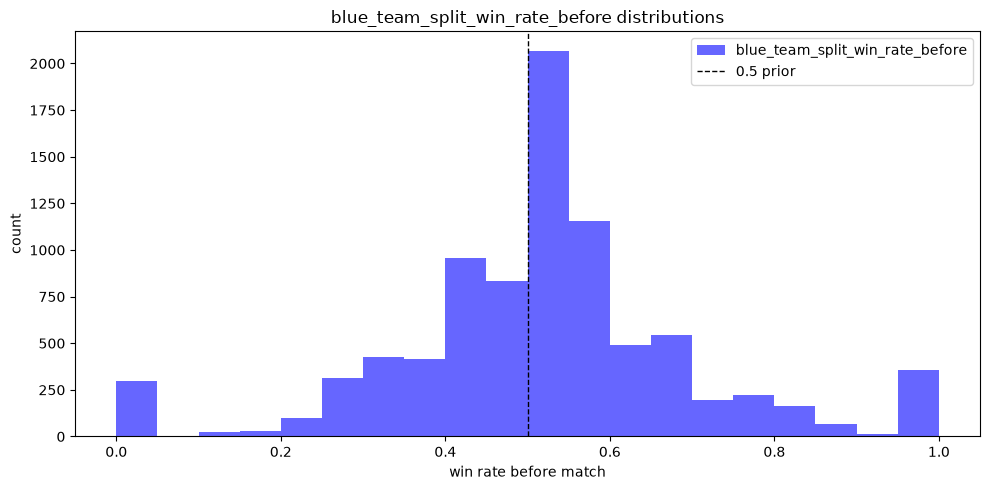

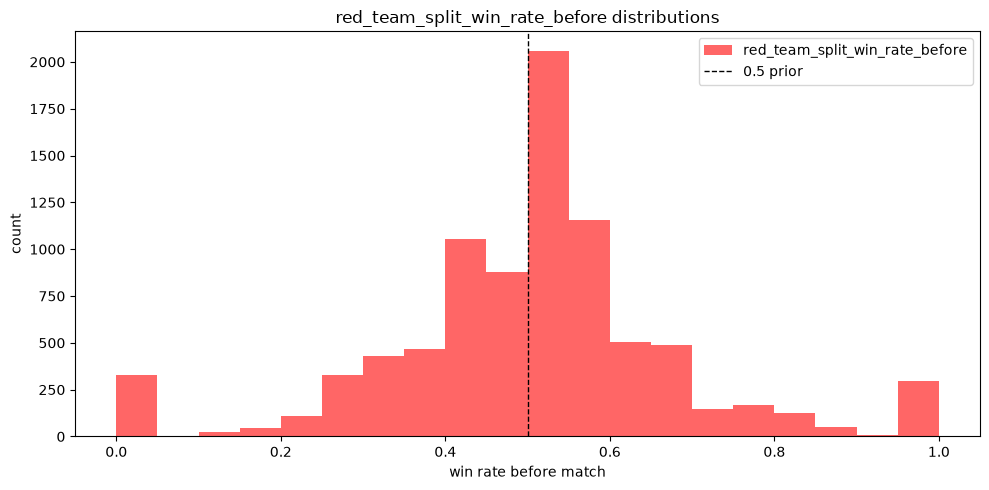

In [6]:
cols = [
    "blue_team_split_win_rate_before",
    "red_team_split_win_rate_before",
]

for col in cols:
    plt.figure(figsize=(10, 5))
    plt.hist(df[col], bins=20, alpha=0.6, label=col, color='red' if col.split('_')[0] == 'red' else 'blue')

    plt.axvline(0.5, color="black", linestyle="--", linewidth=1, label="0.5 prior")
    plt.title(f"{col} distributions")
    plt.xlabel("win rate before match")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [7]:
for side in ["blue", "red"]:
    games_col = f"{side}_team_split_games_before"
    rate_col = f"{side}_team_split_win_rate_before"

    default_rows = (df[games_col] == 0) & (df[rate_col] == 0.5)

    print(f"{side}: {default_rows.sum()} / {len(df)} rows default to 0.5")

blue: 327 / 8677 rows default to 0.5
red: 295 / 8677 rows default to 0.5


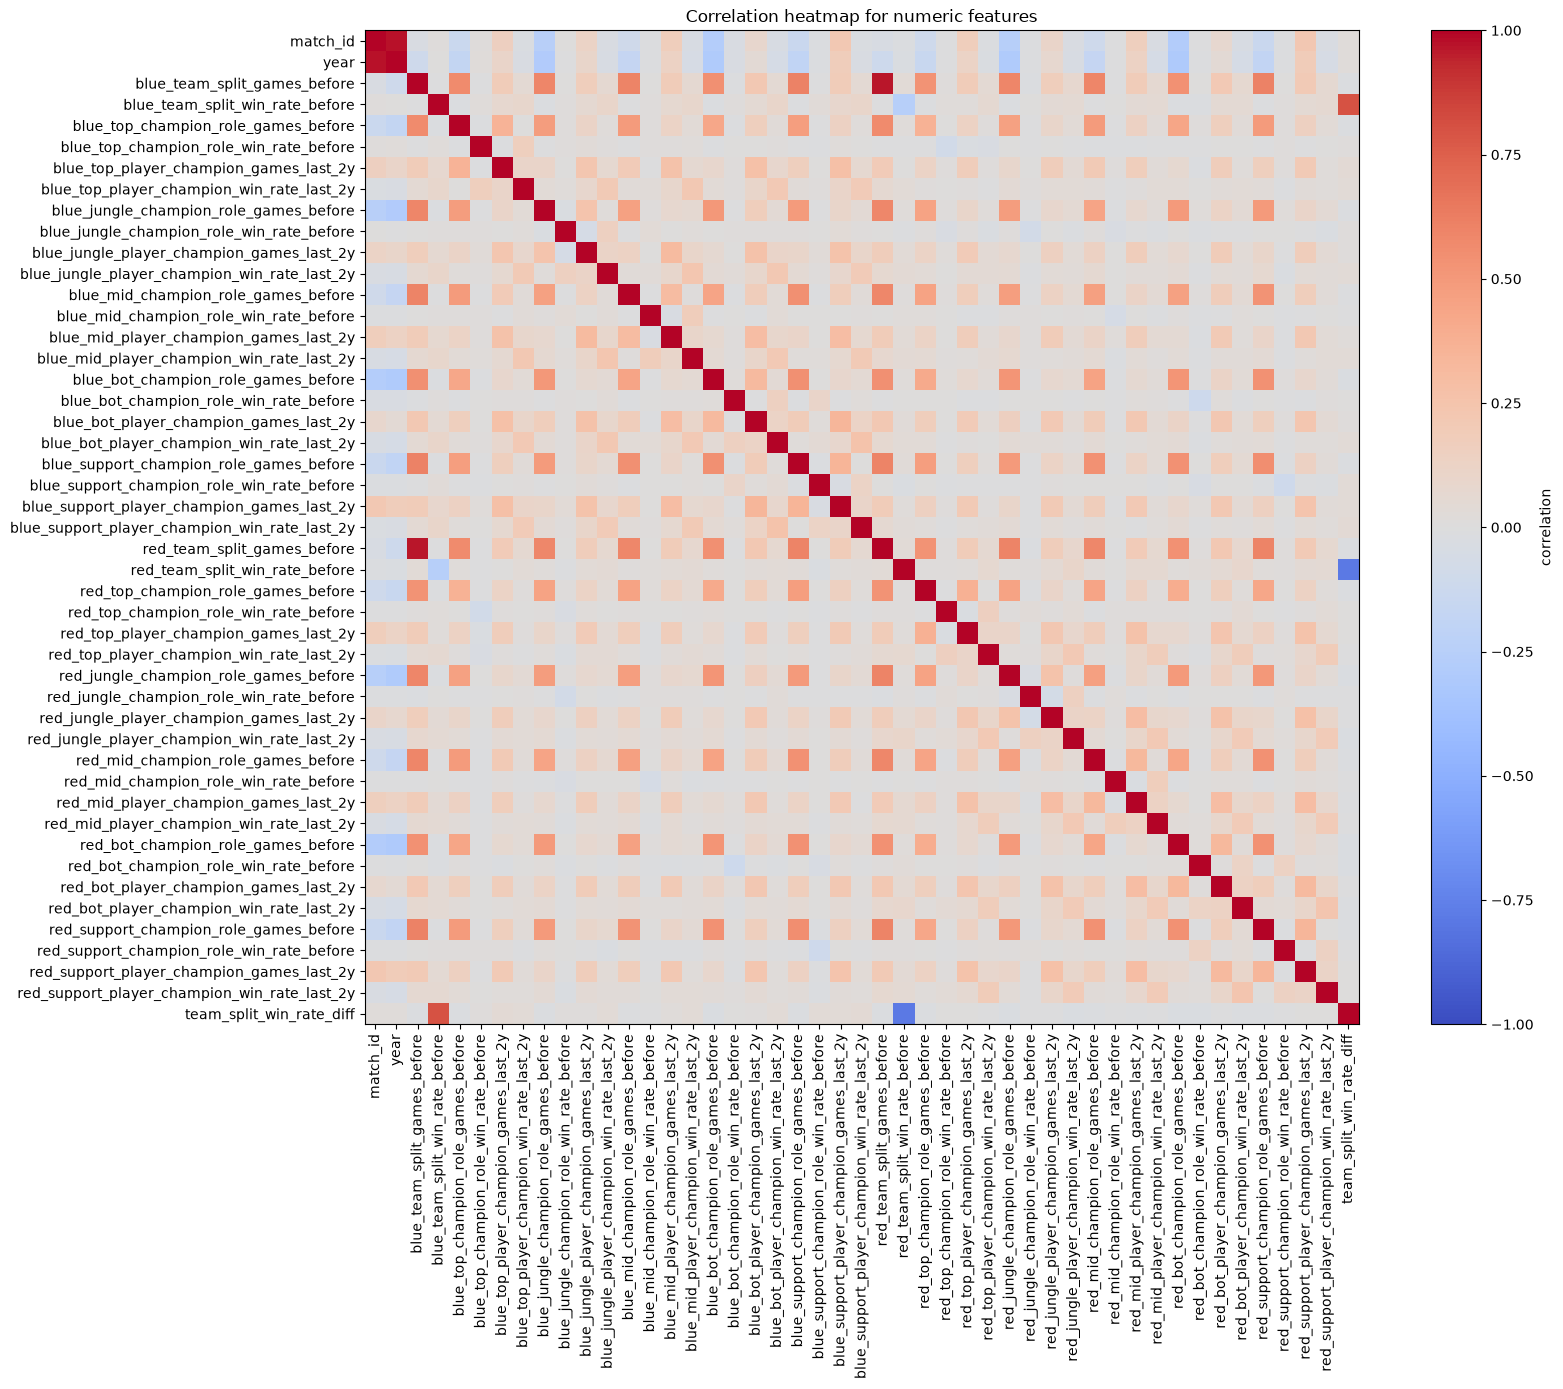

In [8]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure(figsize=(18, 14))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation heatmap for numeric features")
plt.tight_layout()
plt.show()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8677 entries, 0 to 8676
Data columns (total 77 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   match_id                                       8677 non-null   int64  
 1   match_date                                     8677 non-null   object 
 2   region                                         8677 non-null   object 
 3   year                                           8677 non-null   int64  
 4   split                                          8677 non-null   object 
 5   stage                                          8677 non-null   object 
 6   blue_win                                       8677 non-null   bool   
 7   first_pick_side                                8677 non-null   object 
 8   blue_team_name                                 8677 non-null   object 
 9   red_team_name                                  8677 

In [11]:
df.describe()

,match_id,year,blue_team_split_games_before,blue_team_split_win_rate_before,blue_top_champion_role_games_before,blue_top_champion_role_win_rate_before,blue_top_player_champion_games_last_2y,blue_top_player_champion_win_rate_last_2y,blue_jungle_champion_role_games_before,blue_jungle_champion_role_win_rate_before,blue_jungle_player_champion_games_last_2y,blue_jungle_player_champion_win_rate_last_2y,blue_mid_champion_role_games_before,blue_mid_champion_role_win_rate_before,blue_mid_player_champion_games_last_2y,blue_mid_player_champion_win_rate_last_2y,blue_bot_champion_role_games_before,blue_bot_champion_role_win_rate_before,blue_bot_player_champion_games_last_2y,blue_bot_player_champion_win_rate_last_2y,blue_support_champion_role_games_before,blue_support_champion_role_win_rate_before,blue_support_player_champion_games_last_2y,blue_support_player_champion_win_rate_last_2y,red_team_split_games_before,red_team_split_win_rate_before,red_top_champion_role_games_before,red_top_champion_role_win_rate_before,red_top_player_champion_games_last_2y,red_top_player_champion_win_rate_last_2y,red_jungle_champion_role_games_before,red_jungle_champion_role_win_rate_before,red_jungle_player_champion_games_last_2y,red_jungle_player_champion_win_rate_last_2y,red_mid_champion_role_games_before,red_mid_champion_role_win_rate_before,red_mid_player_champion_games_last_2y,red_mid_player_champion_win_rate_last_2y,red_bot_champion_role_games_before,red_bot_champion_role_win_rate_before,red_bot_player_champion_games_last_2y,red_bot_player_champion_win_rate_last_2y,red_support_champion_role_games_before,red_support_champion_role_win_rate_before,red_support_player_champion_games_last_2y,red_support_player_champion_win_rate_last_2y,team_split_win_rate_diff
count,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000,8677.000000
mean,55748.266221,2023.714763,18.082863,0.515739,23.412009,0.518103,8.075026,0.539191,24.263686,0.519355,7.890285,0.546650,21.356229,0.522379,7.054051,0.552028,26.242941,0.520770,8.087357,0.544636,22.260689,0.513589,7.998732,0.540045,18.456379,0.501137,21.552726,0.514207,7.639046,0.543861,24.981560,0.516580,7.814798,0.545864,20.632477,0.519872,6.958050,0.545472,26.998156,0.513079,8.412931,0.542949,22.413622,0.513672,8.069264,0.542025,0.014602
std,12036.393195,1.304364,14.058764,0.186853,28.907860,0.200870,9.649291,0.264339,29.407678,0.196134,8.953645,0.262263,26.213187,0.203933,8.930587,0.266004,35.722949,0.197758,9.079713,0.254740,27.437582,0.204251,9.234079,0.258043,14.437728,0.182311,28.796229,0.208762,9.632670,0.266402,30.105013,0.199023,9.159726,0.264232,25.729578,0.210498,8.882427,0.266933,36.044389,0.195705,9.227227,0.253951,27.685679,0.205502,9.357072,0.256372,0.292436
min,35817.000000,2022.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
25%,45002.000000,2023.000000,7.000000,0.428571,4.000000,0.444444,1.000000,0.428571,4.000000,0.444444,1.000000,0.444444,3.000000,0.450000,1.000000,0.478261,4.000000,0.454545,1.000000,0.444444,3.000000,0.435484,1.000000,0.444444,7.000000,0.416667,3.000000,0.437500,1.000000,0.444444,4.000000,0.444444,1.000000,0.454545,3.000000,0.444444,1.000000,0.454